# TIGER Dataset Radiomics Analysis

Analysis of radiomics features extracted from the TIGER (Tumor InfiltratinG lymphocytes in breast cancER) dataset.

**Dataset**: TIGER Grand Challenge - https://tiger.grand-challenge.org/


## Step 0: Download Example Data

This notebook uses 6 whole-slide images from the TIGER dataset. The data includes:
- H&E WSI images (.tif)
- Tissue region annotations (originally ASAP XML, converted to GeoJSON)

**Data source**: [TIGER Grand Challenge](https://tiger.grand-challenge.org/)

The example data is stored in `example_data/tiger_subset/`.

In [ ]:
import os
from pathlib import Path

# Define paths
EXAMPLE_DATA_DIR = Path("../example_data/tiger_subset")
EXAMPLE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Check if data already exists
tif_files = list(EXAMPLE_DATA_DIR.glob("*.tif"))
xml_files = list(EXAMPLE_DATA_DIR.glob("*.xml"))
geojson_files = list(EXAMPLE_DATA_DIR.glob("*.geojson"))

print(f"Found {len(tif_files)} WSI images")
print(f"Found {len(xml_files)} ASAP XML annotation files")
print(f"Found {len(geojson_files)} GeoJSON annotation files")

if len(tif_files) >= 6 and len(geojson_files) >= 6:
    print("\nExample data is ready!")
else:
    print("\nPlease download the TIGER training data from:")
    print("https://tiger.grand-challenge.org/")
    print("\nThen extract WSIs 100B, 154B, 198B, 207B, 234B, 242B to:")
    print(EXAMPLE_DATA_DIR.resolve())

### Convert ASAP XML to GeoJSON

TIGER annotations are provided in ASAP XML format. The following code converts them to GeoJSON for QuPath import.

QuPath can import GeoJSON directly via **File → Import objects**.

In [ ]:
import xml.etree.ElementTree as ET
import json
from pathlib import Path

def convert_asap_xml_to_geojson(xml_path, output_path=None):
    """
    Convert ASAP XML annotation file to GeoJSON format for QuPath.
    
    Parameters:
        xml_path: Path to ASAP XML file
        output_path: Output GeoJSON path (default: same name with .geojson extension)
    """
    xml_path = Path(xml_path)
    if output_path is None:
        output_path = xml_path.with_suffix('.geojson')
    
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    features = []
    
    for annotation in root.findall('.//Annotation'):
        name = annotation.get('Name', 'Unknown')
        part_of_group = annotation.get('PartOfGroup', 'Unknown')
        
        coords = []
        for coord in annotation.findall('.//Coordinate'):
            x = float(coord.get('X'))
            y = float(coord.get('Y'))
            coords.append([x, y])
        
        if len(coords) >= 3:
            # Close the polygon
            if coords[0] != coords[-1]:
                coords.append(coords[0])
            
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [coords]
                },
                "properties": {
                    "objectType": "annotation",
                    "classification": {
                        "name": part_of_group
                    }
                }
            }
            features.append(feature)
    
    geojson = {
        "type": "FeatureCollection",
        "features": features
    }
    
    with open(output_path, 'w') as f:
        json.dump(geojson, f)
    
    return len(features)

# Convert all XML files if GeoJSON doesn't exist
for xml_file in EXAMPLE_DATA_DIR.glob("*.xml"):
    geojson_file = xml_file.with_suffix('.geojson')
    if not geojson_file.exists():
        n = convert_asap_xml_to_geojson(xml_file, geojson_file)
        print(f"Converted {xml_file.name} -> {geojson_file.name} ({n} annotations)")
    else:
        print(f"{geojson_file.name} already exists")

### Data Structure

Each WSI has annotation files:
```
tiger_subset/
├── 100B.tif        # Whole-slide image
├── 100B.xml        # Original ASAP annotations
├── 100B.geojson    # Converted for QuPath
├── 154B.tif
...
```

The GeoJSON files can be imported directly into QuPath via **File → Import objects**.

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from umap import UMAP
from xgboost import XGBClassifier
import marsilea as ma
import marsilea.plotter as mp
from matplotlib.colors import TwoSlopeNorm

radiomics_dir = "/Users/tamara/Desktop/PyRadiomics/Qupath/radiomics"
output_dir = "/Users/tamara/Desktop/PyRadiomics/QuRad/article_figures"
os.makedirs(output_dir, exist_ok=True)

file_pattern = "*B_radiomics_20260121*.csv"

correlation_threshold = 0.90
n_top_features = 60


/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _drop_constant_cols(df: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    """Drop columns with zero or near-zero variance."""
    nunique = df.nunique(dropna=True)
    keep = nunique[nunique > 1].index
    df = df[keep]
    var = df.var(axis=0, ddof=0)
    return df.loc[:, var.fillna(0.0) > eps]

def prune_correlated_features(df: pd.DataFrame, threshold: float = 0.90) -> tuple:
    """Remove highly correlated features."""
    if df.shape[1] <= 1:
        return df, []
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set()
    mean_corr = corr.mean(axis=0)
    for col in upper.columns:
        hits = upper.index[upper[col] > threshold].tolist()
        for row in hits:
            if row in to_drop or col in to_drop:
                continue
            drop = col if mean_corr[col] >= mean_corr[row] else row
            to_drop.add(drop)
    kept = [c for c in df.columns if c not in to_drop]
    return df[kept], sorted(to_drop)

def compute_feature_importance(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """Compute feature importance using MI, ANOVA, and RF."""
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_filled = X.fillna(X.median())
    
    results = pd.DataFrame(index=X.columns)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_filled, y_enc, random_state=0, n_neighbors=5)
    results['MutualInfo'] = mi_scores
    
    # ANOVA F-test
    f_scores, _ = f_classif(X_filled, y_enc)
    results['ANOVA_F'] = np.nan_to_num(f_scores, nan=0)
    
    # Random Forest importance
    rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=0, n_jobs=-1)
    rf.fit(X_filled, y_enc)
    results['RF_Importance'] = rf.feature_importances_
    
    # Normalize and compute consensus
    for col in ['MutualInfo', 'ANOVA_F', 'RF_Importance']:
        max_val = results[col].max()
        results[col + '_norm'] = results[col] / max_val if max_val > 0 else 0
    
    norm_cols = [c for c in results.columns if c.endswith('_norm')]
    results['Consensus'] = results[norm_cols].mean(axis=1)
    return results.sort_values('Consensus', ascending=False)


## Load Data


In [3]:
files = sorted(glob.glob(os.path.join(radiomics_dir, file_pattern)))
print(f"Found {len(files)} radiomics files:")
for f in files:
    print(f"  - {os.path.basename(f)}")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df['source_file'] = os.path.basename(f)
    df['wsi_id'] = os.path.basename(f).split('_')[0]
    dfs.append(df)

rad = pd.concat(dfs, ignore_index=True)
rad['Classification'] = rad['Classification'].fillna('Unclassified')

print(f"\nTotal rows: {len(rad)}")
print(f"\nClassification distribution:")
print(rad['Classification'].value_counts())


Found 6 radiomics files:
  - 100B_radiomics_20260121_151453.csv
  - 154B_radiomics_20260121_145957.csv
  - 198B_radiomics_20260121_152053.csv
  - 207B_radiomics_20260121_150423.csv
  - 234B_radiomics_20260121_151022.csv
  - 242B_radiomics_20260121_152452.csv

Total rows: 1880

Classification distribution:
Classification
lymphocytes and plasma cells    1638
invasive tumor                   103
tumor-associated stroma           62
healthy glands                    32
rest                              29
necrosis not in-situ              12
in-situ tumor                      4
Name: count, dtype: int64


In [4]:
rad_tissue = rad[rad['ObjectType'].str.lower() == 'annotation'].copy()
rad_cells = rad[rad['ObjectType'].str.lower() == 'detection'].copy()

print(f"Tissue annotations: {len(rad_tissue)}")
print(rad_tissue['Classification'].value_counts())

print(f"\nCell detections (TILs): {len(rad_cells)}")
print(rad_cells['Classification'].value_counts())

Tissue annotations: 242
Classification
invasive tumor             103
tumor-associated stroma     62
healthy glands              32
rest                        29
necrosis not in-situ        12
in-situ tumor                4
Name: count, dtype: int64

Cell detections (TILs): 1638
Classification
lymphocytes and plasma cells    1638
Name: count, dtype: int64


## Tissue-level Radiomics Analysis

Analyzing radiomics features to distinguish between tissue types:
- Invasive tumor
- Tumor-associated stroma  
- Healthy glands

In [5]:
meta_cols = {'Classification', 'ObjectID', 'ObjectType', 'source_file', 'wsi_id'}
feat_cols = [c for c in rad_tissue.columns if c not in meta_cols]

X_all = rad_tissue[feat_cols].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
labels = rad_tissue['Classification'].astype(str)
wsi_ids = rad_tissue['wsi_id'].astype(str)

X_imp = X_all.apply(lambda s: s.fillna(s.median()), axis=0)

X_clean = _drop_constant_cols(X_imp)
print(f"After dropping constants: {X_clean.shape[1]} features")

X_uncorr, dropped = prune_correlated_features(X_clean, threshold=correlation_threshold)
print(f"After removing correlated: {X_uncorr.shape[1]} features (dropped {len(dropped)})")

min_samples = 30
class_counts = labels.value_counts()
keep_classes = class_counts[class_counts >= min_samples].index
mask = labels.isin(keep_classes)

print(f"\nClasses with >= {min_samples} samples: {list(keep_classes)}")
print(f"Samples after filtering: {mask.sum()}")


After dropping constants: 118 features
After removing correlated: 52 features (dropped 66)

Classes with >= 30 samples: ['invasive tumor', 'tumor-associated stroma', 'healthy glands']
Samples after filtering: 197


In [6]:
X_for_imp = X_uncorr.loc[mask]
y_for_imp = labels.loc[mask]

print("Computing feature importance...")
importance_tissue = compute_feature_importance(X_for_imp, y_for_imp)

n_select = min(n_top_features, X_uncorr.shape[1])
top_features = importance_tissue.head(n_select).index.tolist()

print(f"\nTop {n_select} features by importance:")
for i, f in enumerate(top_features[:15], 1):
    score = importance_tissue.loc[f, 'Consensus']
    print(f"  {i:2d}. {f}: {score:.4f}")


Computing feature importance...

Top 52 features by importance:
   1. firstorder_InterquartileRange: 0.8498
   2. firstorder_10Percentile: 0.8451
   3. glrlm_GrayLevelVariance: 0.8185
   4. gldm_DependenceEntropy: 0.8054
   5. glcm_ClusterProminence: 0.7081
   6. firstorder_RootMeanSquared: 0.6965
   7. glcm_DifferenceVariance: 0.6642
   8. glszm_SizeZoneNonUniformityNormalized: 0.5974
   9. glcm_Imc1: 0.5781
  10. glcm_JointEnergy: 0.5725
  11. glszm_GrayLevelNonUniformityNormalized: 0.5565
  12. firstorder_Skewness: 0.5166
  13. glszm_SmallAreaEmphasis: 0.5077
  14. glcm_DifferenceEntropy: 0.4910
  15. glrlm_RunEntropy: 0.4870


In [7]:
X_final = X_uncorr[top_features].loc[mask].fillna(0)
y_final = labels.loc[mask].reset_index(drop=True)
groups = wsi_ids.loc[mask].reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

print(f"Final data: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")
print(f"Classes: {y_final.value_counts().to_dict()}")


Final data: 197 samples, 52 features
Classes: {'invasive tumor': 103, 'tumor-associated stroma': 62, 'healthy glands': 32}


In [8]:
from sklearn.model_selection import GroupKFold

n_splits = 3
cv = GroupKFold(n_splits=n_splits)

print(f"Using {n_splits}-fold GroupKFold CV (grouped by WSI)")
print(f"Number of WSIs: {groups.nunique()}")

print(f"Using {n_splits}-fold Stratified cross-validation\n")

# Random Forest
print("--- RANDOM FOREST ---")
rf = RandomForestClassifier(
    n_estimators=500, max_depth=10, min_samples_split=2,
    class_weight='balanced', random_state=0, n_jobs=-1
)
pred_rf = cross_val_predict(rf, X_scaled, y_final, cv=cv, groups=groups)
f1_rf = f1_score(y_final, pred_rf, average='macro')
print(f"Macro F1: {f1_rf:.4f}")
print(classification_report(y_final, pred_rf, zero_division=0))

Using 3-fold GroupKFold CV (grouped by WSI)
Number of WSIs: 6
Using 3-fold Stratified cross-validation

--- RANDOM FOREST ---
Macro F1: 0.7373
                         precision    recall  f1-score   support

         healthy glands       0.68      0.84      0.75        32
         invasive tumor       0.76      0.76      0.76       103
tumor-associated stroma       0.75      0.66      0.70        62

               accuracy                           0.74       197
              macro avg       0.73      0.75      0.74       197
           weighted avg       0.74      0.74      0.74       197



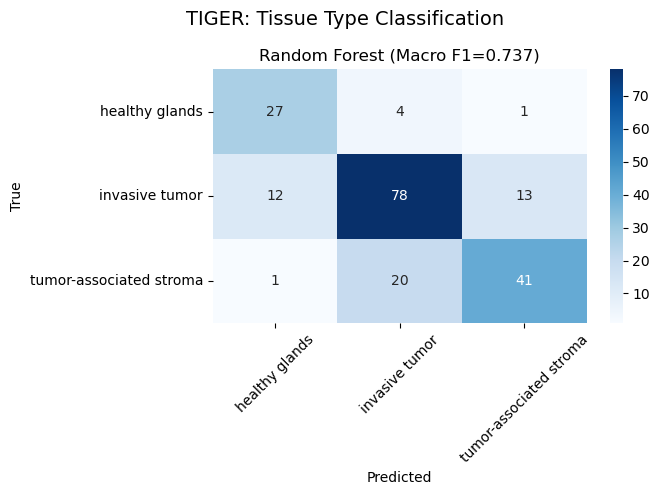

In [9]:
classes = sorted(y_final.unique().tolist())
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

cm_rf = confusion_matrix(y_final, pred_rf, labels=classes)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f'Random Forest (Macro F1={f1_rf:.3f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('TIGER: Tissue Type Classification', fontsize=14)
plt.tight_layout()

plt.show()


Using top 10 features for UMAP


/Users/tamara/anaconda3/envs/pyradiomics_test/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


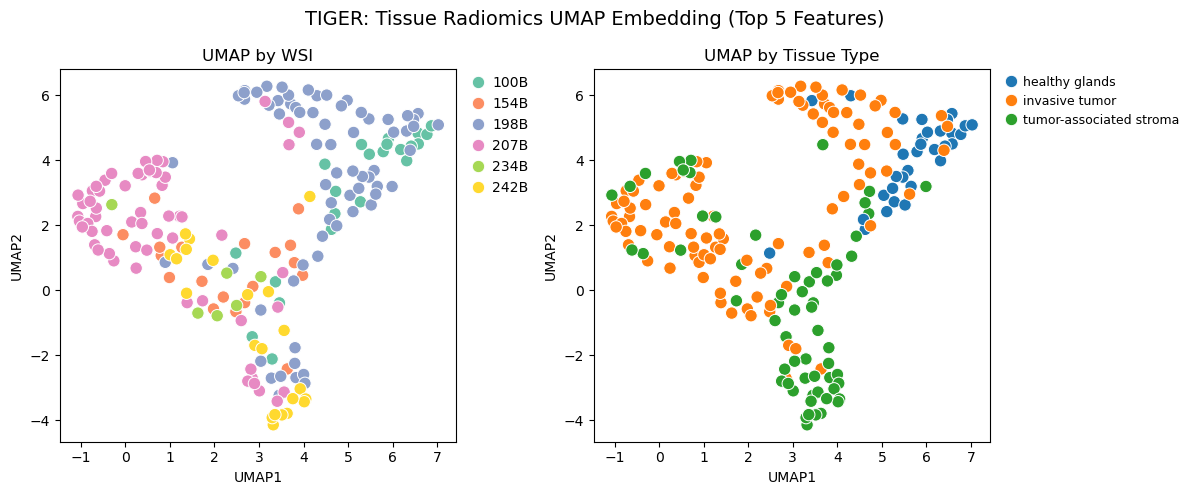

In [10]:
if len(X_scaled) >= 10:
    n_umap_features = 10
    X_umap = X_scaled[:, :n_umap_features]
    print(f"Using top {n_umap_features} features for UMAP")
    
    n_neighbors = min(15, len(X_umap) - 1)
    emb = UMAP(n_neighbors=n_neighbors, min_dist=0.3, random_state=0).fit_transform(X_umap)
    
    umap_df = pd.DataFrame(emb, columns=['UMAP1', 'UMAP2'])
    umap_df['WSI'] = groups.values
    umap_df['Classification'] = y_final.values
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='WSI', 
                    s=80, ax=axes[0], palette='Set2')
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[0].set_title('UMAP by WSI')
    
    sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Classification', 
                    s=80, ax=axes[1])
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    axes[1].set_title('UMAP by Tissue Type')
    
    plt.suptitle('TIGER: Tissue Radiomics UMAP Embedding (Top 5 Features)', fontsize=14)
    plt.tight_layout()
    
    plt.show()


Saved: /Users/tamara/Desktop/PyRadiomics/QuRad/article_figures/tiger_umap_tissue_clean.png


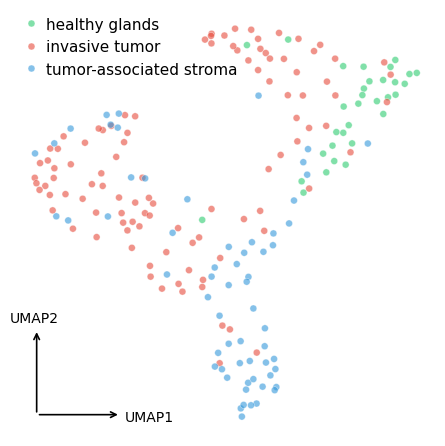

In [11]:
def style_pca_axis(ax, show_arrows=False):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_arrows:
        ax.annotate(
            '',
            xy=(0.25, 0.05),
            xytext=(0.05, 0.05),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))

        ax.annotate(
            '',
            xy=(0.05, 0.25),
            xytext=(0.05, 0.05),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', lw=1.2, color='black'))

        ax.text(0.26, 0.045, 'UMAP1', transform=ax.transAxes,
                ha='left', va='center', fontsize=10)
        ax.text(0.045, 0.26, 'UMAP2', transform=ax.transAxes,
                ha='center', va='bottom', fontsize=10)

tissue_colors = {
    'invasive tumor': '#E74C3C',
    'tumor-associated stroma': '#3498DB', 
    'healthy glands': '#2ECC71'
}

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Classification', 
                s=25, alpha=0.6, palette=tissue_colors, ax=ax)          
ax.legend(title="", fontsize=11, title_fontsize=12, loc='upper left',frameon=False)
plt.tight_layout()
ax.set_xlabel("")
ax.set_ylabel("")
style_pca_axis(ax, show_arrows=True)

out_umap = os.path.join(output_dir, 'tiger_umap_tissue_clean.png')
fig.savefig(out_umap, dpi=300, bbox_inches='tight')
print(f"Saved: {out_umap}")
plt.show()

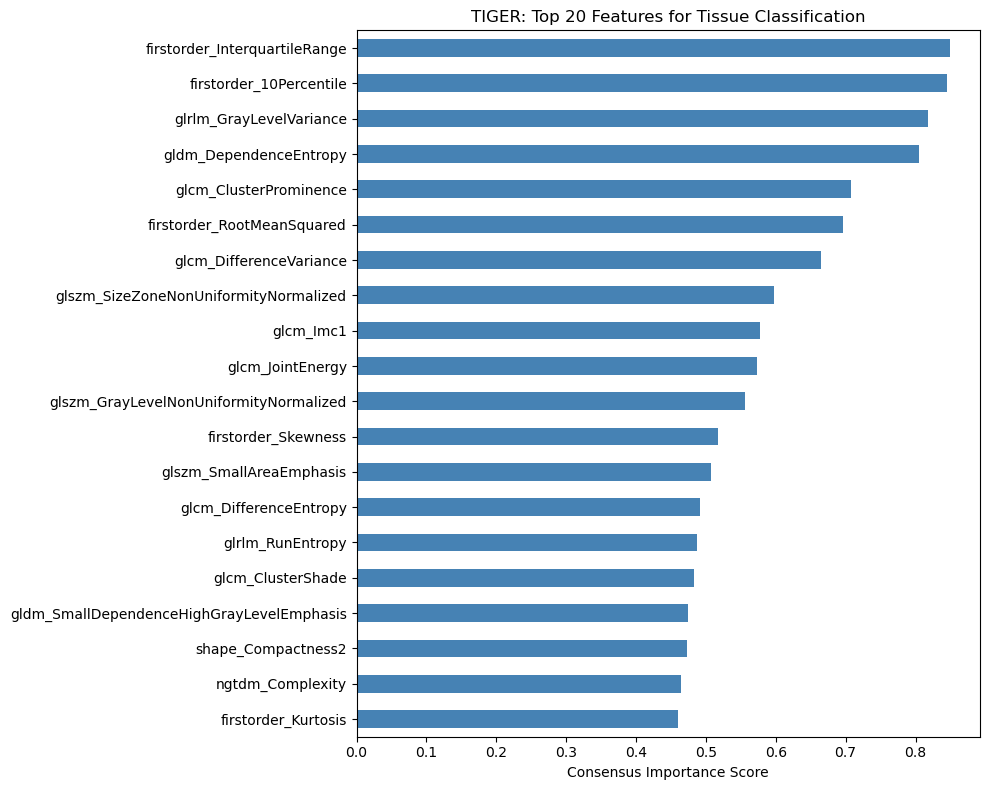

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

imp_plot = importance_tissue['Consensus'].head(20).sort_values(ascending=True)
imp_plot.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('TIGER: Top 20 Features for Tissue Classification')
ax.set_xlabel('Consensus Importance Score')

plt.tight_layout()
plt.show()


Saved: /Users/tamara/Desktop/PyRadiomics/QuRad/article_figures/tiger_heatmap_marsilea_tissue.png


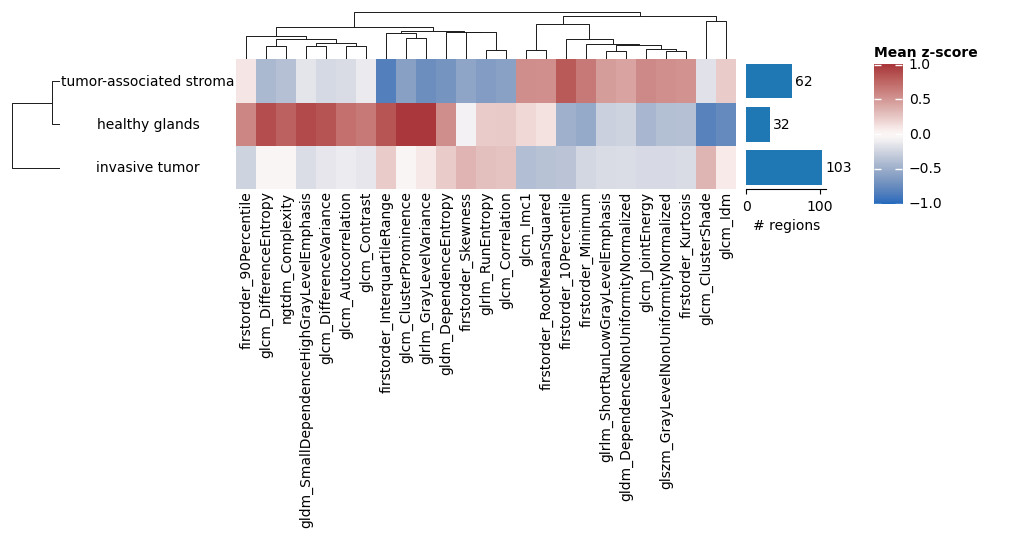

In [13]:
X_z = pd.DataFrame(X_scaled, columns=top_features)
X_z['Classification'] = y_final.values

means = X_z.groupby('Classification').mean()

# Use top features by variance across tissue types
top_feats = means.var(axis=0).sort_values(ascending=False).head(25).index
M = means[top_feats]

# Number of samples per tissue type
n_samples = y_final.value_counts().reindex(M.index)

h = ma.Heatmap(
    M.to_numpy(),
    cmap="vlag",
    norm=TwoSlopeNorm(vcenter=0),
    width=5,
    height=1.3,
    label="Mean z-score",
)

h.add_left(mp.Labels(M.index.tolist(), align="center"))
h.add_bottom(mp.Labels(M.columns.tolist(), rotation=90))
h.add_right(mp.Numbers(n_samples.values, label="# regions"), pad=0.1, size=0.8)

h.add_dendrogram("left")
h.add_dendrogram("top")
h.add_legends("right", pad=0.2)
h.set_margin(0.15)
h.render()

out_marsilea = os.path.join(output_dir, 'tiger_heatmap_marsilea_tissue.png')
plt.savefig(out_marsilea, dpi=300, bbox_inches='tight')
print(f"Saved: {out_marsilea}")
